# Stage 2: BS 与 Heston 期权定价

- **BS 模型**：使用 `hv_20d` 作为波动率
- **Heston 模型**：用 2401-2411 到期期权校准，对 2412 到期期权测试

| 输入 | 输出 |
|------|------|
| `full_option_trading_data.csv` | Heston 校准参数、BS/Heston 在测试集上的 MAE/RMSE/MAPE |

In [1]:
import pandas as pd
import numpy as np
from OptionPricingModel import (
    OptionPricingModel,
    HestonParams,
    extract_expiry_yymm,
    compute_metrics,
    set_seed,
    SEED,
)

set_seed()

!pip3 install QuantLib
# Heston 需 QuantLib，未安装则后续校准会报错
HESTON_AVAILABLE = False
try:
    import QuantLib as ql
    print("QuantLib 已安装，可进行 Heston 校准与定价")
    HESTON_AVAILABLE = True
except ImportError:
    print("QuantLib 未安装，Heston 部分将不可用。安装: pip install QuantLib-Python")

  Using cached quantlib-1.41-cp38-abi3-macosx_11_0_arm64.whl.metadata (1.1 kB)
Using cached quantlib-1.41-cp38-abi3-macosx_11_0_arm64.whl (15.3 MB)
QuantLib 已安装，可进行 Heston 校准与定价


In [2]:
# 加载数据
df = pd.read_csv("full_option_trading_data.csv", index_col=0)
df["date"] = pd.to_datetime(df["date"])
df["maturity_date"] = pd.to_datetime(df["maturity_date"])
print(f"总记录数: {len(df)}")
df.head(3)

总记录数: 55092


,order_book_id,date,prev_settlement,total_turnover,low,high,close,settlement,limit_up,contract_multiplier,...,underlying_high,underlying_low,hv_20d,risk_free_rate,moneyness(S/K),log_moneyness(ln(S/K)),moneyness(K/S),log_moneyness(ln(K/S)),call_put,euro_american
0,IO2401C2900,2024-01-11,383.8,2143800.0,397.4,407.6,397.4,398.6,711.4,100,...,3311.1137,3266.7911,0.136375,0.024992,1.136439,0.127899,0.879942,-0.127899,0,0
1,IO2401C2900,2024-01-12,398.6,4243820.0,393.2,406.8,396.0,391.2,728.0,100,...,3310.4704,3279.6987,0.135810,0.025172,1.132471,0.124402,0.883025,-0.124402,0,0
2,IO2401C2900,2024-01-15,391.2,2550880.0,366.4,391.6,379.2,380.8,719.6,100,...,3306.9217,3261.2687,0.135586,0.025212,1.131352,0.123413,0.883899,-0.123413,0,0


In [3]:
# 提取到期月份 YYMM，划分训练集(2401-2411)与测试集(2412)
df["expiry_yymm"] = df["order_book_id"].apply(extract_expiry_yymm)
train_yymm = [f"24{i:02d}" for i in range(1, 12)]  # 2401-2411
df_train = df[df["expiry_yymm"].isin(train_yymm)].copy()
df_test = df[df["expiry_yymm"] == "2412"].copy()
print(f"训练集(2401-2411): {len(df_train)} 条")
print(f"测试集(2412): {len(df_test)} 条")

训练集(2401-2411): 45854 条
测试集(2412): 9238 条


In [ ]:
# 数据清洗：过滤无效值
def clean_option_data(d):
    d = d.dropna(subset=["underlying_close", "strike_price", "time_to_expire", "risk_free_rate", "close", "hv_20d", "iv"])
    d = d[d["time_to_expire"] > 5/365]  # 剔除到期时间小于5天的"末日轮"
    d = d[d["close"] >= 0.2]  # 期权最低结算价 0.2
    d = d[d["hv_20d"] > 1e-6]
    d = d[d["iv"] > 1e-8]  # 排除 iv 缺失或异常小值
    return d

df_train = clean_option_data(df_train)
df_test = clean_option_data(df_test)
print(f"清洗后 训练集: {len(df_train)}, 测试集: {len(df_test)}")

清洗后 训练集: 42349, 测试集: 8701


## BS 定价（使用 hv_20d）

In [5]:
model = OptionPricingModel()
# 训练集 BS 定价
pred_bs_train = model.price_bs_batch(df_train)
# 测试集 BS 定价
pred_bs_test = model.price_bs_batch(df_test)
y_train = df_train["close"].values
y_test = df_test["close"].values
print("BS 定价结果:")
print("  训练集:", compute_metrics(y_train, pred_bs_train))
print("  测试集:", compute_metrics(y_test, pred_bs_test))

BS 定价结果:
  训练集: {'MAE': 23.586908412028563, 'RMSE': 35.41061947941353, 'MAPE': 38.79418090725718}
  测试集: {'MAE': 42.46122601631207, 'RMSE': 59.83901058095787, 'MAPE': 67.3605543789001}


## Heston 校准（2401-2411 训练集）

使用 scipy 优化最小化模型价与市场价的相对误差。需安装 QuantLib: `pip install QuantLib-Python`

In [6]:
# Heston 校准（采样以加速，可调 max_samples）
# 需安装 QuantLib: pip install QuantLib-Python
try:
    params = model.calibrate_heston(
        df_train,
        price_col="close",
        method="least_squares",
        max_samples=1500,
    )
    print("校准得到的 Heston 参数:")
    print(f"  kappa={params.kappa:.4f}, theta={params.theta:.4f}, sigma={params.sigma:.4f}")
    print(f"  rho={params.rho:.4f}, v0={params.v0:.4f}")
    HESTON_AVAILABLE = True
except ImportError as e:
    print("QuantLib 未安装，跳过 Heston 校准。安装: pip install QuantLib-Python")
    HESTON_AVAILABLE = False

QuantLib 未安装，跳过 Heston 校准。安装: pip install QuantLib-Python


## Heston 测试集定价（2412）

In [7]:
# 对测试集进行 Heston 定价（使用校准参数）
if HESTON_AVAILABLE:
    pred_heston_test = model.price_heston_batch(df_test)
    print("Heston 测试集:", compute_metrics(y_test, pred_heston_test))
else:
    pred_heston_test = np.full(len(df_test), np.nan)

## 对比 BS vs Heston

In [8]:
# 汇总对比（BS 与 Heston 均在 IO2412 测试集上评估）
rows = [{"模型": "BS (hv_20d)", "MAE": compute_metrics(y_test, pred_bs_test)["MAE"],
        "RMSE": compute_metrics(y_test, pred_bs_test)["RMSE"],
        "MAPE(%)": compute_metrics(y_test, pred_bs_test)["MAPE"]}]
if HESTON_AVAILABLE:
    rows.append({"模型": "Heston (校准)", "MAE": compute_metrics(y_test, pred_heston_test)["MAE"],
                 "RMSE": compute_metrics(y_test, pred_heston_test)["RMSE"],
                 "MAPE(%)": compute_metrics(y_test, pred_heston_test)["MAPE"]})
summary = pd.DataFrame(rows)
summary

,模型,MAE,RMSE,MAPE(%)
0,BS (hv_20d),42.461226,59.839011,67.360554


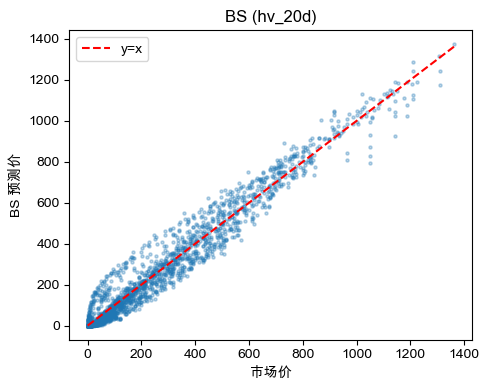

In [9]:
# 可视化：预测 vs 实际（测试集抽样）
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Arial Unicode MS']

n_show = min(2000, len(df_test))
idx = np.random.RandomState(SEED).choice(len(df_test), n_show, replace=False)
yt = y_test[idx]
n_plots = 2 if HESTON_AVAILABLE else 1
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
if n_plots == 1:
    axes = [axes]
axes[0].scatter(yt, pred_bs_test[idx], alpha=0.3, s=5)
axes[0].plot([0, yt.max()], [0, yt.max()], "r--", label="y=x")
axes[0].set_xlabel("市场价"); axes[0].set_ylabel("BS 预测价"); axes[0].set_title("BS (hv_20d)"); axes[0].legend()
if HESTON_AVAILABLE:
    axes[1].scatter(yt, pred_heston_test[idx], alpha=0.3, s=5)
    axes[1].plot([0, yt.max()], [0, yt.max()], "r--", label="y=x")
    axes[1].set_xlabel("市场价"); axes[1].set_ylabel("Heston 预测价"); axes[1].set_title("Heston (校准)"); axes[1].legend()
plt.tight_layout()
plt.show()

## 扩展：Heston 参数由神经网络提供（预留接口）

将来可将 `set_heston_params_provider` 传入一个函数，根据 (S, T, r, ...) 动态返回 HestonParams，实现神经网络校准。

In [10]:
# 示例：如何接入神经网络参数（当前使用固定校准参数）
# def nn_params_provider(S, T, r, **kwargs) -> HestonParams:
#     features = ...  # 从神经网络输入
#     kappa, theta, sigma, rho, v0 = model.predict(features)
#     return HestonParams(kappa=kappa, theta=theta, sigma=sigma, rho=rho, v0=v0)
# model.set_heston_params_provider(nn_params_provider)